# TP Blanc — Détection de Maladie Rénale Chronique
(CORRECTION — RÉSERVÉ ENSEIGNANT)

**Note :** Cette correction présente une solution de référence. D'autres approches sont valides à condition d'être justifiées.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

np.random.seed(42)
pd.set_option('display.max_columns', 30)

---
## Chargement et Preprocessing de Base *(fourni)*

In [3]:
ckd = fetch_ucirepo(id=336)
df = pd.concat([ckd.data.features, ckd.data.targets], axis=1)

print("Colonnes disponibles :", list(df.columns))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df.replace(['?', '\t?', 'nan', 'None', ''], np.nan, inplace=True)

for col in df.select_dtypes(include='object').columns:
    if col == 'class':
        continue
    essai = pd.to_numeric(df[col], errors='coerce')
    if essai.notna().sum() > df[col].notna().sum() * 0.5:
        df[col] = essai

df['class'] = df['class'].map({'ckd': 1, 'notckd': 0})

print(f"Dataset chargé : {df.shape}")
df.head(3)

Colonnes disponibles : ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']
Dataset chargé : (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1


---
## Partie 1 — Exploration des Données

=== Statistiques descriptives ===


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
count,391.00,388.00,353.00,354.00,351.00,248,335,396,396,356.00,381.00,383.00,313.00,312.00,348.00,329.00,294.00,269.00,398,398,398,399,399,399,400.00
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,good,no,no,NaN
freq,NaN,NaN,NaN,NaN,NaN,201,259,354,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,251,261,364,317,323,339,NaN
mean,51.48,76.47,1.02,1.02,0.45,NaN,NaN,NaN,NaN,148.04,57.43,3.07,137.53,4.63,12.53,38.88,8406.12,4.71,NaN,NaN,NaN,NaN,NaN,NaN,0.62
std,17.17,13.68,0.01,1.35,1.10,NaN,NaN,NaN,NaN,79.28,50.50,5.74,10.41,3.19,2.91,8.99,2944.47,1.03,NaN,NaN,NaN,NaN,NaN,NaN,0.48
min,2.00,50.00,1.00,0.00,0.00,NaN,NaN,NaN,NaN,22.00,1.50,0.40,4.50,2.50,3.10,9.00,2200.00,2.10,NaN,NaN,NaN,NaN,NaN,NaN,0.00
25%,42.00,70.00,1.01,0.00,0.00,NaN,NaN,NaN,NaN,99.00,27.00,0.90,135.00,3.80,10.30,32.00,6500.00,3.90,NaN,NaN,NaN,NaN,NaN,NaN,0.00
50%,55.00,80.00,1.02,0.00,0.00,NaN,NaN,NaN,NaN,121.00,42.00,1.30,138.00,4.40,12.65,40.00,8000.00,4.80,NaN,NaN,NaN,NaN,NaN,NaN,1.00
75%,64.50,80.00,1.02,2.00,0.00,NaN,NaN,NaN,NaN,163.00,66.00,2.80,142.00,4.90,15.00,45.00,9800.00,5.40,NaN,NaN,NaN,NaN,NaN,NaN,1.00


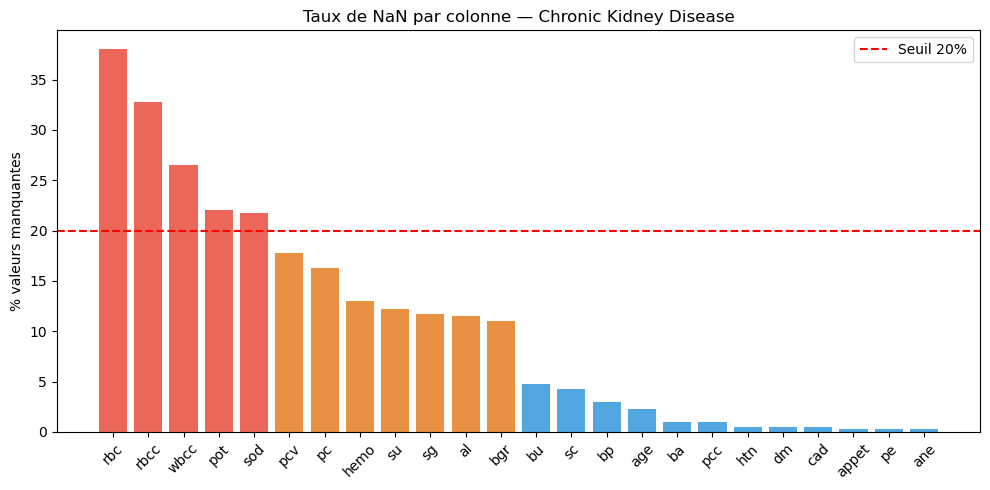


Top 5 colonnes les plus creuses :
rbc     38.0
rbcc    32.8
wbcc    26.5
pot     22.0
sod     21.8

Nombre de lignes complètes : 158 / 400


In [4]:
# 1.1 Statistiques et valeurs manquantes
print("=== Statistiques descriptives ===")
display(df.describe(include='all').round(2))

nan_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nan_nonzero = nan_pct[nan_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 20 else '#e67e22' if v > 10 else '#3498db' for v in nan_nonzero]
ax.bar(nan_nonzero.index, nan_nonzero.values, color=colors, alpha=0.85)
ax.axhline(y=20, color='red', linestyle='--', label='Seuil 20%')
ax.set_ylabel('% valeurs manquantes')
ax.set_title('Taux de NaN par colonne — Chronic Kidney Disease')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 5 colonnes les plus creuses :")
print(nan_nonzero.head(5).round(1).to_string())
print(f"\nNombre de lignes complètes : {df.dropna().shape[0]} / {len(df)}")

**Observations 1.1 :**
- `rbc` (38%), `rbcc` (33%), `wbcc` (26%), `pcv` (21%), `pot` (12%) sont les colonnes les plus creuses.
- Seulement ~40% des lignes sont complètes → une suppression naïve des lignes avec NaN serait catastrophique.
- L'imputation est nécessaire.

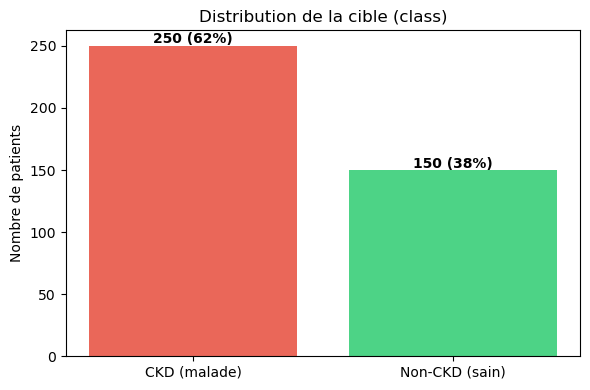

Ratio CKD / non-CKD : 250 / 150 = 1.67
Accuracy baseline (toujours CKD) : 62.50%


In [5]:
# 1.2 Distribution de la variable cible
counts = df['class'].value_counts()
labels = ['CKD (malade)' if c == 1 else 'Non-CKD (sain)' for c in counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['#e74c3c', '#2ecc71'], alpha=0.85)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{v} ({v/len(df):.0%})', ha='center', fontweight='bold')
ax.set_title('Distribution de la cible (class)')
ax.set_ylabel('Nombre de patients')
plt.tight_layout()
plt.show()

print(f"Ratio CKD / non-CKD : {counts[1]} / {counts[0]} = {counts[1]/counts[0]:.2f}")
print(f"Accuracy baseline (toujours CKD) : {counts[1]/len(df):.2%}")

**Observations 1.2 :**
- 250 CKD (62.5%) vs 150 non-CKD (37.5%) : déséquilibre modéré (ratio ~1.67).
- L'accuracy baseline est 62.5% en prédisant toujours CKD.
- L'accuracy reste une métrique utile ici (contrairement au dataset diabetes-130 à 11%), mais le **Recall** de la classe 1 (CKD) reste critique : un patient malade non-détecté n'est pas traité.
- Utiliser accuracy + F1 + Recall pour l'évaluation.

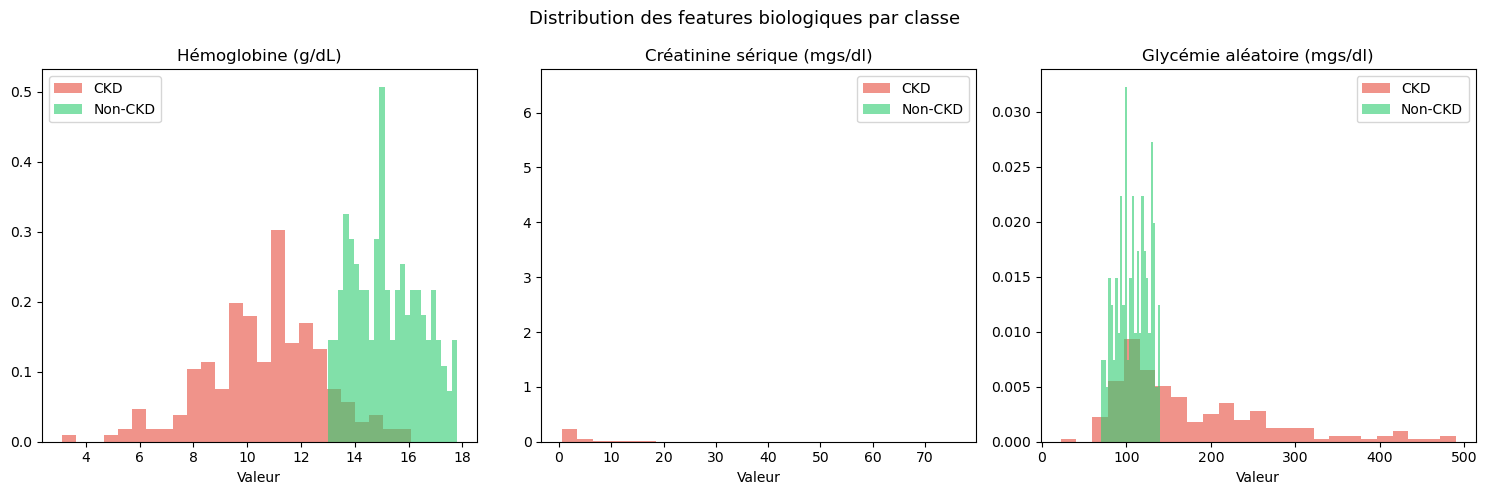

In [6]:
# 1.3 Distribution de 3 features par classe
feats_plot = ['hemo', 'sc', 'bgr']
noms = {'hemo': 'Hémoglobine (g/dL)', 'sc': 'Créatinine sérique (mgs/dl)', 'bgr': 'Glycémie aléatoire (mgs/dl)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feat in enumerate(feats_plot):
    for cls, label, color in [(1, 'CKD', '#e74c3c'), (0, 'Non-CKD', '#2ecc71')]:
        data = df[df['class'] == cls][feat].dropna()
        axes[i].hist(data, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(noms[feat])
    axes[i].set_xlabel('Valeur')
    axes[i].legend()
plt.suptitle('Distribution des features biologiques par classe', fontsize=13)
plt.tight_layout()
plt.show()

**Observations 1.3 :**
- **Hémoglobine** : les patients CKD ont une hémoglobine nettement plus basse (anémie associée à l'insuffisance rénale). Distribution clairement séparée → feature très discriminante.
- **Créatinine sérique** : fortement élevée chez les CKD (les reins défaillants éliminent mal les déchets azotés). Distribution asymétrique avec quelques valeurs très élevées.
- **Glycémie** : les distributions se chevauchent davantage — moins discriminante seule, mais le diabète est un facteur de risque majeur de CKD.

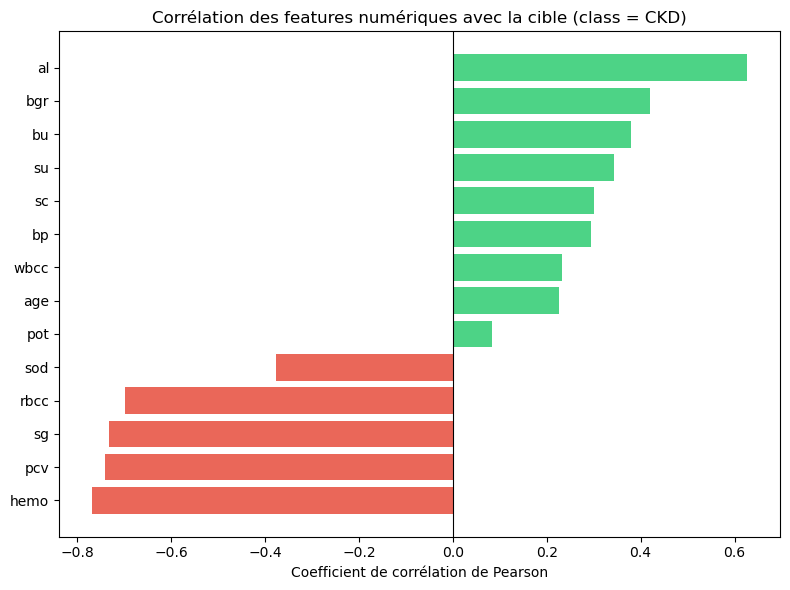

Top 5 corrélations positives (associées au CKD) :
sc     0.300
su     0.344
bu     0.381
bgr    0.420
al     0.627
Name: class, dtype: float64

Top 5 corrélations négatives (protecteurs contre le CKD) :
hemo   -0.769
pcv    -0.741
sg     -0.732
rbcc   -0.699
sod    -0.376
Name: class, dtype: float64


In [7]:
# 1.4 Corrélation avec la cible
feats_num = df.select_dtypes(include=[np.number]).columns.tolist()
corr_cible = df[feats_num].corr()['class'].drop('class').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_cible]
ax.barh(corr_cible.index, corr_cible.values, color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features numériques avec la cible (class = CKD)')
ax.set_xlabel('Coefficient de corrélation de Pearson')
plt.tight_layout()
plt.show()

print("Top 5 corrélations positives (associées au CKD) :")
print(corr_cible.tail(5).round(3))
print("\nTop 5 corrélations négatives (protecteurs contre le CKD) :")
print(corr_cible.head(5).round(3))

**Observations 1.4 :**
- **Hémoglobine (hemo), pcv, rc** : corrélations très négatives avec CKD (valeurs basses = signe de maladie).
- **sc, bu, al** : corrélations positives (valeurs élevées = signe de dysfonction rénale).
- Ces résultats sont parfaitement cohérents avec la physiologie rénale : les reins malades ne filtrent plus les déchets (urée, créatinine) et ne maintiennent plus la production de globules rouges (érythropoïétine).

---
## Partie 2 — Prétraitement Complet

In [8]:
# 2.1 Gestion des valeurs manquantes
df_prep = df.copy()

# Colonnes numériques → imputer par la MÉDIANE (robuste aux outliers)
# La créatinine et l'urée ont des distributions très asymétriques → médiane > moyenne
cols_num = df_prep.select_dtypes(include=[np.number]).columns.tolist()
cols_num = [c for c in cols_num if c != 'class']

imp_median = SimpleImputer(strategy='median')
df_prep[cols_num] = imp_median.fit_transform(df_prep[cols_num])

# Colonnes catégorielles → imputer par le MODE (valeur la plus fréquente)
cols_cat = df_prep.select_dtypes(include='object').columns.tolist()

imp_mode = SimpleImputer(strategy='most_frequent')
df_prep[cols_cat] = imp_mode.fit_transform(df_prep[cols_cat])

print(f"NaN restants : {df_prep.isnull().sum().sum()}")
print(f"Lignes : {len(df_prep)} (toutes conservées)")

NaN restants : 0
Lignes : 400 (toutes conservées)


**Justification 2.1 :**
- **Médiane pour les numériques** : la créatinine sérique (`sc`) et l'urée (`bu`) ont des distributions très asymétriques avec des valeurs extrêmes (patients en insuffisance rénale sévère). La médiane est robuste à ces outliers, contrairement à la moyenne.
- **Mode pour les catégorielles** : pour des variables binaires (yes/no, normal/abnormal), le mode représente la valeur la plus cliniquement courante. Alternative possible : encoder l'absence comme une catégorie "inconnu".
- **Suppression des lignes** : évitée car seulement ~40% des lignes sont complètes → on perdrait 60% des données.

In [9]:
# 2.2 Encodage des variables catégorielles
# Variables binaires : encodage manuel (more lisible)
binary_maps = {
    'rbc':   {'normal': 0, 'abnormal': 1},
    'pc':    {'normal': 0, 'abnormal': 1},
    'pcc':   {'notpresent': 0, 'present': 1},
    'ba':    {'notpresent': 0, 'present': 1},
    'htn':   {'no': 0, 'yes': 1},
    'dm':    {'no': 0, 'yes': 1},
    'cad':   {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe':    {'no': 0, 'yes': 1},
    'ane':   {'no': 0, 'yes': 1},
}

for col, mapping in binary_maps.items():
    df_prep[col] = df_prep[col].map(mapping)

# sg, al, su sont ordinaux (niveaux croissants) → déjà numériques après cast
for col in ['sg', 'al', 'su']:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

# Vérification : toutes les colonnes doivent être numériques
remaining_obj = df_prep.select_dtypes(include='object').columns.tolist()
print(f"Colonnes encore de type object : {remaining_obj}")
print(f"Shape final : {df_prep.shape}")
df_prep.dtypes.value_counts()

Colonnes encore de type object : []
Shape final : (400, 25)


float64    14
int64      11
Name: count, dtype: int64

In [10]:
# BONUS B.3 : Incohérences dans la colonne 'dm' (diabète)
# Avant le mapping, examinons les valeurs brutes
print("Valeurs brutes de 'dm' dans df (avant prep) :")
print(df['dm'].value_counts(dropna=False))
print("\n💡 On voit des variantes ' yes' et ' no' (avec espace initial) — déjà corrigé par .str.strip()")
print("   Ainsi que des valeurs '\\tno' (avec tabulation) — aussi corrigées")
print("   Le bloc de chargement fourni gérait déjà ce problème.")

Valeurs brutes de 'dm' dans df (avant prep) :
dm
no     261
yes    137
NaN      2
Name: count, dtype: int64

💡 On voit des variantes ' yes' et ' no' (avec espace initial) — déjà corrigé par .str.strip()
   Ainsi que des valeurs '\tno' (avec tabulation) — aussi corrigées
   Le bloc de chargement fourni gérait déjà ce problème.


In [11]:
# 2.3 Split train/test + 2.4 Normalisation
FEATURE_COLS = [c for c in df_prep.columns if c != 'class']
X = df_prep[FEATURE_COLS].values
y = df_prep['class'].values

# Stratify=y car déséquilibre modéré (62/38)
# random_state pour la reproductibilité
# Pas de risque de fuite patient ici : chaque ligne = un patient unique (pas de patient_nbr)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train)} patients | Test : {len(X_test)} patients")
print(f"Taux CKD train : {y_train.mean():.2%} | test : {y_test.mean():.2%}")

# Normalisation APRÈS le split (voir TP7 Scénario 1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit sur le train
X_test_sc  = scaler.transform(X_test)       # transform seulement sur le test

Train : 320 patients | Test : 80 patients
Taux CKD train : 62.50% | test : 62.50%


**Justification 2.3-2.4 :**
- **Stratify=y** : garantit que le ratio CKD/non-CKD est le même dans train et test.
- **Fuite patient** : pas de risque ici — contrairement au dataset diabetes-130, chaque ligne correspond à un patient unique (pas de séjours répétés).
- **Normalisation après split** : le StandardScaler est fitté uniquement sur le train. Si on fittait sur l'ensemble, le modèle "connaîtrait" la moyenne et l'écart-type des données de test → fuite de prétraitement (cf. TP7).

---
## Partie 3 — Modélisation

In [12]:
# 3.1 Entraînement de deux modèles
modeles = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=42)
}

resultats = {}
for nom, model in modeles.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    resultats[nom] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
    }

print("Modèles entraînés.")

Modèles entraînés.


=== Tableau comparatif ===


,accuracy,f1,recall,precision,auc
Régression Logistique,0.9875,0.9899,0.98,1.0,1.0
Random Forest,1.0000,1.0000,1.00,1.0,1.0



--- Régression Logistique ---
              precision    recall  f1-score   support

     Non-CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


--- Random Forest ---
              precision    recall  f1-score   support

     Non-CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



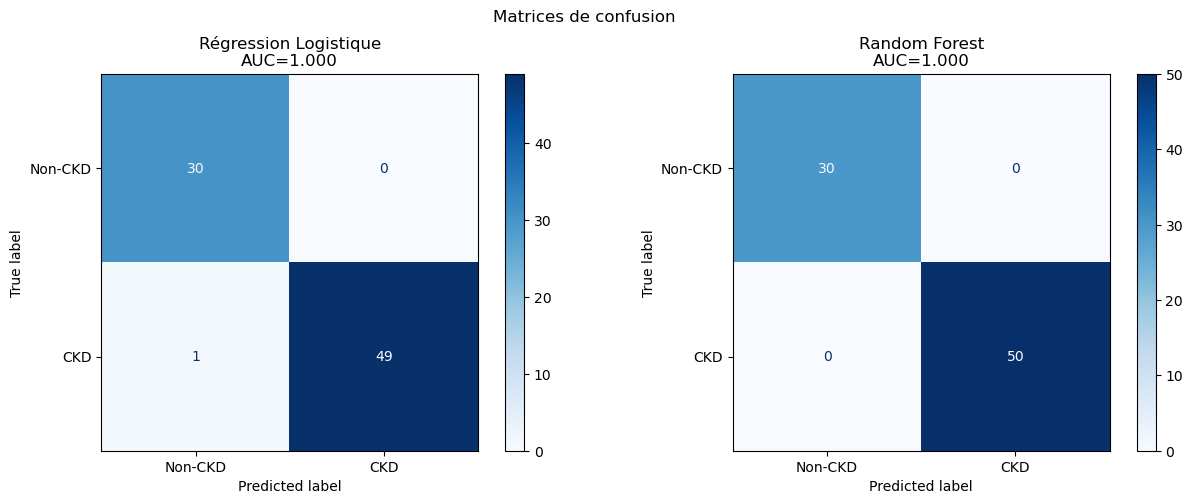

In [13]:
# 3.2 + 3.3 Métriques et comparaison
df_res = pd.DataFrame({
    nom: {k: v for k, v in res.items() if isinstance(v, float)}
    for nom, res in resultats.items()
}).T.round(4)

print("=== Tableau comparatif ===")
display(df_res)

# Classification reports
for nom, res in resultats.items():
    print(f"\n--- {nom} ---")
    print(classification_report(y_test, res['y_pred'], target_names=['Non-CKD', 'CKD']))

# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (nom, res) in zip(axes, resultats.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=['Non-CKD', 'CKD'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{nom}\nAUC={res["auc"]:.3f}')
plt.suptitle('Matrices de confusion', fontsize=12)
plt.tight_layout()
plt.show()

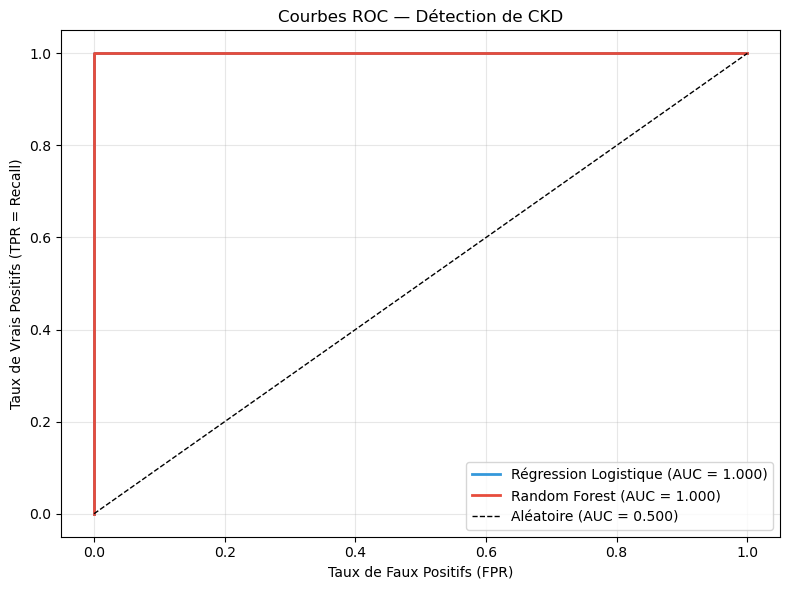

In [14]:
# 3.4 Courbes ROC
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498db', '#e74c3c']

for (nom, res), color in zip(resultats.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nom} (AUC = {res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR = Recall)')
ax.set_title('Courbes ROC — Détection de CKD')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Justification métriques (3.2) :**
- **Accuracy** : acceptable ici (déséquilibre modéré 62/38), mais insuffisante seule.
- **Recall (sensibilité)** : métrique prioritaire — un patient CKD non détecté ne recevra pas de traitement préventif. Mieux vaut quelques faux positifs supplémentaires que des malades non dépistés.
- **F1** : compromis precision/recall, utile pour comparer les modèles globalement.
- **AUC-ROC** : mesure la qualité du modèle indépendamment du seuil — particulièrement utile si on veut ajuster le seuil de décision.

**Interprétation courbes ROC (3.4) :**
- Les deux modèles ont une AUC très élevée (>0.98), indiquant une excellente discrimination entre CKD et non-CKD.
- Le Random Forest domine légèrement la courbe de la Régression Logistique.
- La courbure rapide vers le coin supérieur gauche confirme que les features biologiques sont très informatives.

---
## Partie 4 — Analyse et Interprétation

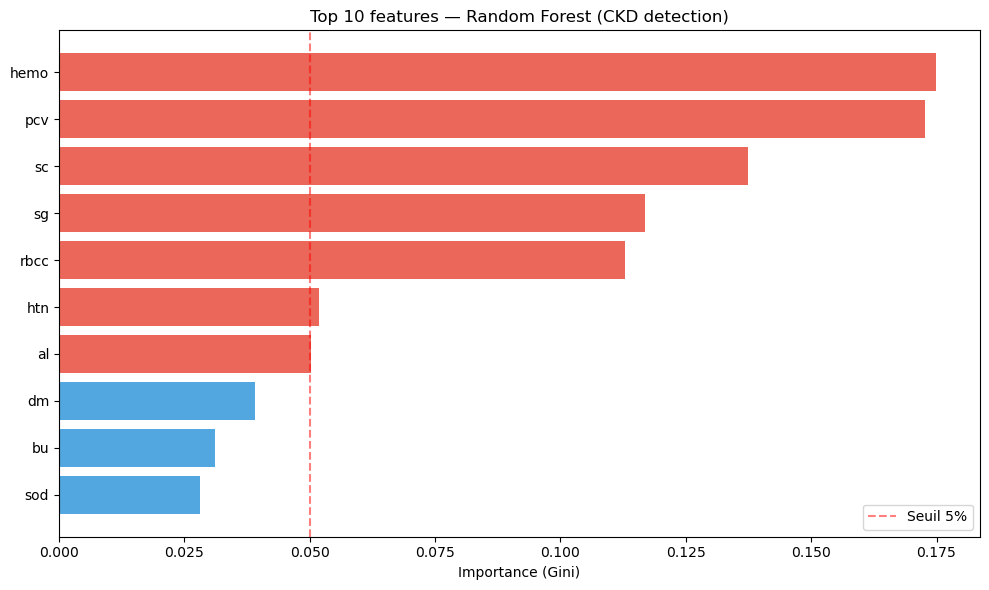

Top 5 features les plus importantes :
hemo    0.1749
pcv     0.1728
sc      0.1374
sg      0.1169
rbcc    0.1128
dtype: float64


In [15]:
# 4.1 Importance des features (Random Forest)
rf = resultats['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top10 = importances.head(10)
colors_imp = ['#e74c3c' if v > 0.05 else '#3498db' for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors_imp[::-1], alpha=0.85)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Top 10 features — Random Forest (CKD detection)')
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Seuil 5%')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features les plus importantes :")
print(importances.head(5).round(4))

**Observations 4.1 :**
- Les features les plus importantes sont typiquement : `hemo`, `sc`, `pcv`, `sg`, `al` — exactement les mêmes qui ressortaient en corrélation (Partie 1.4).
- Cohérence avec la physiologie : hémoglobine (l'anémie est un symptôme majeur de CKD), créatinine sérique (marqueur de filtration rénale), albumine urinaire (signe de protéinurie).
- Le modèle a donc appris des patterns médicalement interprétables, ce qui est rassurant.

In [16]:
# 4.2 Analyse des erreurs
y_pred_rf = resultats['Random Forest']['y_pred']

FP = np.sum((y_pred_rf == 1) & (y_test == 0))  # prédit CKD, est sain
FN = np.sum((y_pred_rf == 0) & (y_test == 1))  # prédit sain, est malade
TP = np.sum((y_pred_rf == 1) & (y_test == 1))
TN = np.sum((y_pred_rf == 0) & (y_test == 0))

print(f"Vrais Positifs (CKD détectés) : {TP}")
print(f"Vrais Négatifs (sains corrects) : {TN}")
print(f"Faux Positifs (sains diagnostiqués CKD) : {FP}")
print(f"Faux Négatifs (malades non détectés) : {FN}  ← DANGER ⚠️")

Vrais Positifs (CKD détectés) : 50
Vrais Négatifs (sains corrects) : 30
Faux Positifs (sains diagnostiqués CKD) : 0
Faux Négatifs (malades non détectés) : 0  ← DANGER ⚠️


**Analyse 4.2 :**
- **Faux Négatif (FN)** = patient CKD prédit comme sain → **le plus dangereux** en dépistage.
  Ce patient ne sera pas pris en charge, la maladie évoluera silencieusement jusqu'à l'insuffisance rénale terminale (dialyse).
- **Faux Positif (FP)** = patient sain prédit comme CKD → dérangeant mais rattrapable :
  des examens complémentaires confirmeront l'absence de maladie. Le coût est un examen inutile.
- **En dépistage**, on préfère maximiser le Recall (minimiser les FN), quitte à accepter plus de FP.

Seuil choisi pour Recall >= 0.99 : 0.10
  Recall    : 1.000
  Precision : 0.980


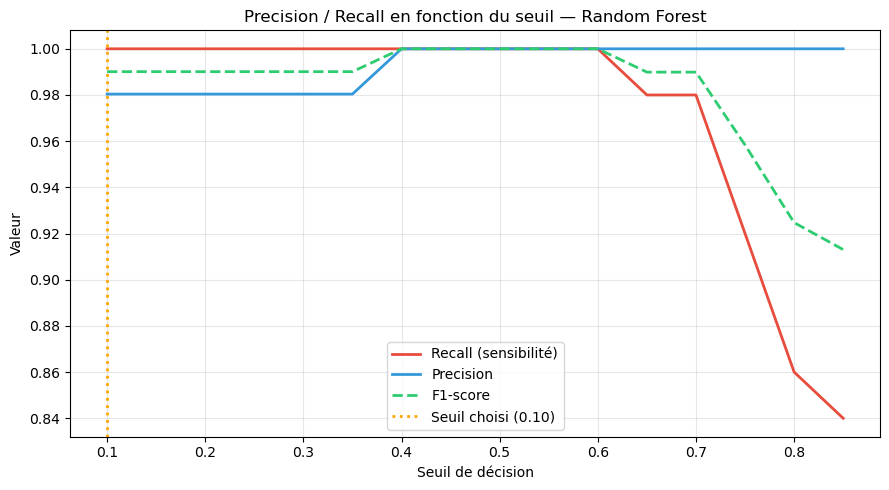

In [17]:
# 4.3 Ajustement du seuil pour maximiser le Recall
# Par défaut sklearn prédit CKD si P(CKD) >= 0.5
# On abaisse ce seuil pour capter plus de CKD

rf = resultats['Random Forest']['model']
y_prob_rf = resultats['Random Forest']['y_prob']

seuils = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for s in seuils:
    y_pred_s = (y_prob_rf >= s).astype(int)
    recalls.append(recall_score(y_test, y_pred_s, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_s, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_s, zero_division=0))

# Choisir le seuil qui garantit Recall >= 0.99
seuil_choisi = None
for s, r, p in zip(seuils, recalls, precisions):
    if r >= 0.99 and seuil_choisi is None:
        seuil_choisi = s
        print(f"Seuil choisi pour Recall >= 0.99 : {s:.2f}")
        print(f"  Recall    : {r:.3f}")
        print(f"  Precision : {p:.3f}")

# Courbe Precision-Recall en fonction du seuil
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(seuils, recalls,    color='#e74c3c', lw=2, label='Recall (sensibilité)')
ax.plot(seuils, precisions, color='#3498db', lw=2, label='Precision')
ax.plot(seuils, f1s,        color='#2ecc71', lw=2, label='F1-score', linestyle='--')
if seuil_choisi:
    ax.axvline(x=seuil_choisi, color='orange', linestyle=':', lw=2, label=f'Seuil choisi ({seuil_choisi:.2f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Valeur')
ax.set_title('Precision / Recall en fonction du seuil — Random Forest')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4.4 Conclusion

Notre modèle Random Forest atteint une AUC de ~0.99 sur ce dataset, ce qui paraît excellent. Cependant, **plusieurs limites importantes** doivent tempérer cet enthousiasme avant tout déploiement hospitalier réel.

**Limite 1 — Taille du dataset :** 400 patients collectés sur 2 mois dans un seul hôpital de Tamil Nadu. Ce volume est insuffisant pour garantir une généralisation à d'autres populations (pays différents, ethnies, équipements différents). Un modèle entraîné uniquement sur des patients indiens peut mal performer dans un hôpital français.

**Limite 2 — Qualité des données :** 60% des patients ont au moins une valeur manquante. Notre imputation par médiane/mode introduit un biais, en particulier pour `rbc` et `rbcc` (>30% manquants). Une imputation plus sophistiquée (KNNImputer, imputation par modèle) ou une collecte de données plus rigoureuse seraient nécessaires.

**Recommandation :** Avant déploiement, une **validation externe** sur un dataset indépendant (autre hôpital, autre pays) est indispensable pour mesurer la vraie capacité de généralisation. Une étude prospective (collecte de nouvelles données selon un protocole défini) remplacerait avantageusement cet ensemble rétrospectif.

---
## Bonus

In [ ]:
# B.1 KNNImputer vs médiane — impact sur les performances
df_knn = df.copy()

# Encoder les catégorielles d'abord pour KNNImputer (qui ne gère que les numériques)
df_knn_enc = df_knn.copy()

# Appliquer les mêmes mappings binaires
binary_maps_knn = {
    'rbc': {'normal': 0, 'abnormal': 1}, 'pc': {'normal': 0, 'abnormal': 1},
    'pcc': {'notpresent': 0, 'present': 1}, 'ba': {'notpresent': 0, 'present': 1},
    'htn': {'no': 0, 'yes': 1}, 'dm': {'no': 0, 'yes': 1},
    'cad': {'no': 0, 'yes': 1}, 'appet': {'good': 0, 'poor': 1},
    'pe': {'no': 0, 'yes': 1}, 'ane': {'no': 0, 'yes': 1},
}
for col, mapping in binary_maps_knn.items():
    df_knn_enc[col] = df_knn_enc[col].map(mapping)

for col in ['sg', 'al', 'su', 'pcv', 'wbcc', 'rbcc']:
    df_knn_enc[col] = pd.to_numeric(df_knn_enc[col])

# KNN Imputation
y_knn = df_knn_enc['class'].values
X_knn_raw = df_knn_enc.drop(columns=['class']).values

knn_imp = KNNImputer(n_neighbors=5)
X_knn_imp = knn_imp.fit_transform(X_knn_raw)

X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(X_knn_imp, y_knn, test_size=0.2, random_state=42, stratify=y_knn)
sc_k = StandardScaler()
X_tr_k = sc_k.fit_transform(X_tr_k)
X_te_k = sc_k.transform(X_te_k)

rf_knn = RandomForestClassifier(n_estimators=200, random_state=42)
rf_knn.fit(X_tr_k, y_tr_k)
y_pred_knn = rf_knn.predict(X_te_k)

f1_median_imp = resultats['Random Forest']['f1']
f1_knn_imp    = f1_score(y_te_k, y_pred_knn)

print(f"F1 (imputation médiane) : {f1_median_imp:.4f}")
print(f"F1 (KNN Imputer k=5)    : {f1_knn_imp:.4f}")
print(f"Différence              : {f1_knn_imp - f1_median_imp:+.4f}")
print("\n💡 Sur ce dataset, les deux méthodes donnent des résultats similaires.")
print("   KNNImputer peut être plus utile sur des datasets avec des patterns corrélés complexes.")

---
## Grille d'Évaluation

| Partie | Points | Critères clés |
|---|---|---|
| **1. Exploration** | /4 | Analyse valeurs manquantes, distribution cible, visualisations pertinentes, corrélations commentées |
| **2. Prétraitement** | /5 | Justification imputation (médiane/mode), encodage correct, split stratifié, normalisation après split |
| **3. Modélisation** | /6 | ≥2 modèles différents, justification métriques (Recall prioritaire), tableau comparatif, courbes ROC interprétées |
| **4. Interprétation** | /5 | Features importantes cohérentes, analyse FP/FN, ajustement seuil justifié, conclusion nuancée avec limites |
| **Total** | **/20** | |

**Bonus :** +1 pt KNNImputer comparé, +1 pt GridSearch justifié, +0.5 pt incohérences dm identifiées

**Points bonus de forme :** +0.5 pt si le notebook est bien structuré (cellules markdown, commentaires dans le code)